Exercice 1 — MLP from Scratch

In [1]:
import numpy as np

# ============================================================
# FONCTIONS D'ACTIVATION
# ============================================================

def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ============================================================
# ÉTAPE 1 — Initialiser les poids et biais
# ============================================================
np.random.seed(42)

# W1 : (2 entrées → 3 neurones cachés)
W1 = np.random.randn(2, 3)
b1 = np.zeros((1, 3))

# W2 : (3 neurones cachés → 1 sortie)
W2 = np.random.randn(3, 1)
b2 = np.zeros((1, 1))

print("W1 :\n", W1)
print("b1 :", b1)
print("W2 :\n", W2)
print("b2 :", b2)

# ============================================================
# ÉTAPE 2 — Forward Propagation
# ============================================================

def forward_propagation(X):
    # Couche cachée
    Z1 = np.dot(X, W1) + b1   # Somme pondérée
    A1 = relu(Z1)              # Activation ReLU

    # Couche de sortie
    Z2 = np.dot(A1, W2) + b2  # Somme pondérée
    A2 = sigmoid(Z2)           # Activation Sigmoid

    return A1, A2

# ============================================================
# ÉTAPE 3 — Prédictions
# ============================================================

# Cas 1 : x1=2, x2=3
X1 = np.array([[2, 3]])
A1_cas1, output_cas1 = forward_propagation(X1)

print("\n--- Cas 1 : Input [2, 3] ---")
print(f"Couche cachée (après ReLU)   : {A1_cas1}")
print(f"Sortie (après Sigmoid)        : {output_cas1}")
print(f"Prédiction                    : {1 if output_cas1[0][0] >= 0.5 else 0}")

# Cas 2 : x1=1, x2=5
X2 = np.array([[1, 5]])
A1_cas2, output_cas2 = forward_propagation(X2)

print("\n--- Cas 2 : Input [1, 5] ---")
print(f"Couche cachée (après ReLU)   : {A1_cas2}")
print(f"Sortie (après Sigmoid)        : {output_cas2}")
print(f"Prédiction                    : {1 if output_cas2[0][0] >= 0.5 else 0}")

W1 :
 [[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]]
b1 : [[0. 0. 0.]]
W2 :
 [[ 1.57921282]
 [ 0.76743473]
 [-0.46947439]]
b2 : [[0.]]

--- Cas 1 : Input [2, 3] ---
Couche cachée (après ReLU)   : [[5.56251788 0.         0.59296621]]
Sortie (après Sigmoid)        : [[0.99979779]]
Prédiction                    : 1

--- Cas 2 : Input [1, 5] ---
Couche cachée (après ReLU)   : [[8.11186344 0.         0.        ]]
Sortie (après Sigmoid)        : [[0.99999727]]
Prédiction                    : 1


Exercice 2 — Backpropagation avec Gradient Descent

In [3]:
import numpy as np

# ============================================================
# DONNÉES
# ============================================================
x1 = 6     # Heures d'étude
x2 = 75    # Score précédent

w1 = 0.4
w2 = 0.6
b  = 5

y_true = 85
lr = 0.01

# ============================================================
# ÉTAPE 1 — Prédiction (Forward)
# ============================================================
y_pred = (x1 * w1) + (x2 * w2) + b
print(f"Prédiction : {y_pred}")

# ============================================================
# ÉTAPE 2 — Loss (MSE)
# ============================================================
loss = 0.5 * (y_true - y_pred) ** 2
print(f"Loss       : {loss}")

# ============================================================
# ÉTAPE 3 — Gradients
# ============================================================
erreur  = y_true - y_pred

grad_w1 = -erreur * x1
grad_w2 = -erreur * x2
grad_b  = -erreur

print(f"\nGradients :")
print(f"  grad_w1 = {grad_w1}")
print(f"  grad_w2 = {grad_w2}")
print(f"  grad_b  = {grad_b}")

# ============================================================
# ÉTAPE 4 — Mise à jour des poids
# ============================================================
w1_new = w1 - lr * grad_w1
w2_new = w2 - lr * grad_w2
b_new  = b  - lr * grad_b

print(f"\nPoids mis à jour :")
print(f"  w1 : {w1} → {w1_new}")
print(f"  w2 : {w2} → {w2_new}")
print(f"  b  : {b}  → {b_new}")

# ============================================================
# INTERPRÉTATION
# ============================================================
print(f"\n Interprétation :")
print(f"  Erreur initiale     : {y_true - y_pred:.2f} points")
print(f"  Le modèle prédisait : {y_pred} (trop {'bas' if y_pred < y_true else 'haut'})")
print(f"  Les poids augmentent pour corriger cette erreur")

Prédiction : 52.4
Loss       : 531.38

Gradients :
  grad_w1 = -195.60000000000002
  grad_w2 = -2445.0
  grad_b  = -32.6

Poids mis à jour :
  w1 : 0.4 → 2.3560000000000003
  w2 : 0.6 → 25.05
  b  : 5  → 5.326

 Interprétation :
  Erreur initiale     : 32.60 points
  Le modèle prédisait : 52.4 (trop bas)
  Les poids augmentent pour corriger cette erreur


Exercice 3 — Comparer les fonctions d'activation

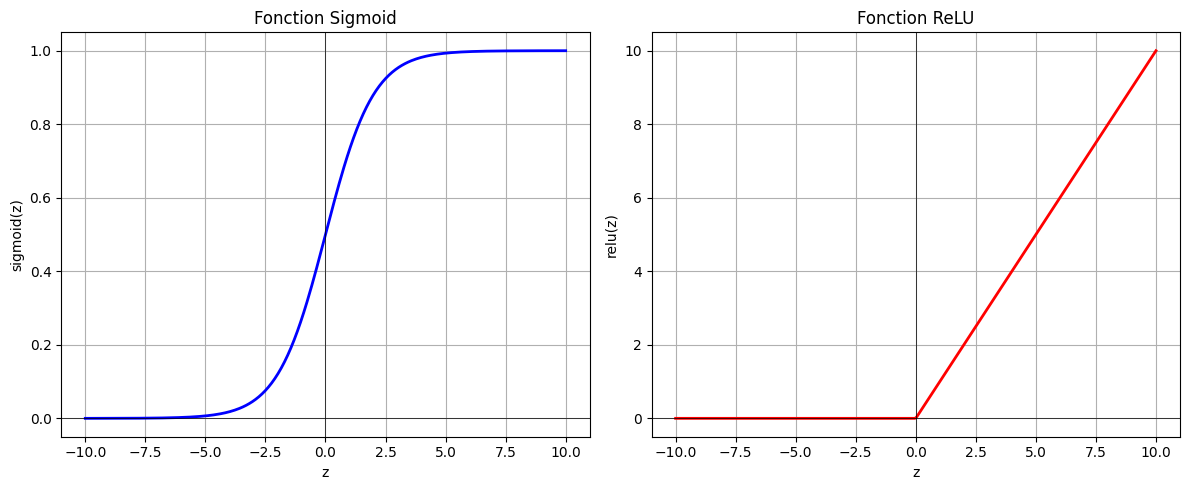

    z |     Step |    Sigmoid |     ReLU


   -5 |        0 |     0.0067 |        0
   -1 |        0 |     0.2689 |        0
    0 |        0 |     0.5000 |        0
    1 |        1 |     0.7311 |        1
    5 |        1 |     0.9933 |        5

 COMPARAISON DES FONCTIONS :

1 Fonction qui donne uniquement des sorties binaires (0 ou 1) :
    → STEP FUNCTION
    Elle retourne exactement 0 ou 1, rien entre les deux.

2 Fonction qui fait une transition fluide entre les valeurs :
    → SIGMOID
    Elle passe doucement de 0 à 1, utile pour les probabilités.

3 Fonction qui met les négatifs à 0 mais garde les positifs :
    → ReLU
    relu(-5) = 0  |  relu(3) = 3

Pourquoi ReLU est la plus utilisée en Deep Learning ?
    - Calcul très rapide (juste max(0,x))
    - Pas de problème de gradient qui disparaît
    - Fonctionne très bien sur les grands réseaux

Pourquoi Sigmoid est bonne pour la classification binaire ?
    - Retourne une valeur entre 0 et 1
    - On l'interprète comme une prob

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ÉTAPE 1 — Implémenter les 3 fonctions
# ============================================================

def step_function(z):
    return np.where(z > 0, 1, 0)   # 1 si z>0, sinon 0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))    # Valeur entre 0 et 1

def relu(z):
    return np.maximum(0, z)         # max(0, x)

# ============================================================
# ÉTAPE 2 — Visualiser Sigmoid et ReLU
# ============================================================

z = np.linspace(-10, 10, 300)  # 300 points entre -10 et 10

plt.figure(figsize=(12, 5))

# Sigmoid
plt.subplot(1, 2, 1)
plt.plot(z, sigmoid(z), color='blue', linewidth=2)
plt.title('Fonction Sigmoid')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)

# ReLU
plt.subplot(1, 2, 2)
plt.plot(z, relu(z), color='red', linewidth=2)
plt.title('Fonction ReLU')
plt.xlabel('z')
plt.ylabel('relu(z)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# ÉTAPE 3 — Comparer les comportements
# ============================================================

test_values = [-5, -1, 0, 1, 5]



print(f"{'z':>5} | {'Step':>8} | {'Sigmoid':>10} | {'ReLU':>8}")
print("\n")
for z_val in test_values:
    s  = step_function(z_val)
    sg = sigmoid(z_val)
    r  = relu(z_val)
    print(f"{z_val:>5} | {s:>8} | {sg:>10.4f} | {r:>8}")
print("\n")

# ============================================================
# ÉTAPE 4 — Réponses aux questions
# ============================================================

print("""
 COMPARAISON DES FONCTIONS :

1 Fonction qui donne uniquement des sorties binaires (0 ou 1) :
    → STEP FUNCTION
    Elle retourne exactement 0 ou 1, rien entre les deux.

2 Fonction qui fait une transition fluide entre les valeurs :
    → SIGMOID
    Elle passe doucement de 0 à 1, utile pour les probabilités.

3 Fonction qui met les négatifs à 0 mais garde les positifs :
    → ReLU
    relu(-5) = 0  |  relu(3) = 3

Pourquoi ReLU est la plus utilisée en Deep Learning ?
    - Calcul très rapide (juste max(0,x))
    - Pas de problème de gradient qui disparaît
    - Fonctionne très bien sur les grands réseaux

Pourquoi Sigmoid est bonne pour la classification binaire ?
    - Retourne une valeur entre 0 et 1
    - On l'interprète comme une probabilité
    - Ex: 0.8 → 80% de chance que ce soit la classe 1

Faiblesses de la Step Function ?
    - Gradient = 0 partout → impossible d'apprendre !
    - Pas de valeurs intermédiaires → pas de nuance
    - Inutilisable avec la backpropagation
""")

Exercice 4 — Forward Propagation réseau 3 couches (prix de maison)

In [6]:
import numpy as np

# ============================================================
# DONNÉES
# ============================================================
x1 = 2000  # Superficie
x2 = 3     # Chambres

# Couche 1
W1 = np.array([0.5, 0.7])
b1 = 10000

# Couche 2
W2 = np.array([0.6, 0.8])
b2 = 20000

# Couche sortie
W3 = 1.2
b3 = 30000

# ============================================================
# FONCTION D'ACTIVATION
# ============================================================
def relu(z):
    return max(0, z)

# ============================================================
# FORWARD PROPAGATION
# ============================================================
X = np.array([x1, x2])

# Couche 1
Z1 = np.dot(X, W1) + b1
A1 = relu(Z1)
print(f"Couche 1 → Z1 = {Z1:.2f} | A1 = {A1:.2f}")

# Couche 2
# Les deux poids s'appliquent sur la même sortie A1
Z2 = (A1 * W2[0]) + (A1 * W2[1]) + b2
A2 = relu(Z2)
print(f"Couche 2 → Z2 = {Z2:.2f} | A2 = {A2:.2f}")

# Couche sortie
Z3 = (A2 * W3) + b3
print(f"Sortie   → Z3 = {Z3:.2f}")

print(f"\n Prix prédit : {Z3:,.2f} $")

Couche 1 → Z1 = 11002.10 | A1 = 11002.10
Couche 2 → Z2 = 35402.94 | A2 = 35402.94
Sortie   → Z3 = 72483.53

 Prix prédit : 72,483.53 $


Exercice 5 — Entraînement complet Forward + Backward

In [7]:
import numpy as np

# ============================================================
# ÉTAPE 1 — Initialiser les données
# ============================================================
x = np.array([6, 75])   # heures d'étude, score précédent
y_true = 85             # score réel

# ============================================================
# ÉTAPE 2 — Initialiser poids et biais
# ============================================================
w = np.array([0.4, 0.6])  # w1=0.4, w2=0.6
b = 5                      # biais

lr = 0.01  # learning rate

# ============================================================
# ÉTAPE 3 — Forward Propagation
# ============================================================
def forward(x, w, b):
    return np.dot(x, w) + b   # somme pondérée

y_pred = forward(x, w, b)
print(f"Prédiction initiale : {y_pred}")

# ============================================================
# ÉTAPE 4 — Erreur
# ============================================================
erreur = y_true - y_pred
loss   = 0.5 * erreur ** 2
print(f" Erreur              : {erreur:.4f}")
print(f" Loss (MSE)          : {loss:.4f}")

# ============================================================
# ÉTAPE 5 — Gradients
# ============================================================
grad_w = -erreur * x   # vecteur [grad_w1, grad_w2]
grad_b = -erreur

print(f"\n Gradients :")
print(f"   grad_w1 = {grad_w[0]:.4f}")
print(f"   grad_w2 = {grad_w[1]:.4f}")
print(f"   grad_b  = {grad_b:.4f}")

# ============================================================
# ÉTAPE 6 — Mise à jour des poids
# ============================================================
w_new = w - lr * grad_w
b_new = b - lr * grad_b

print(f"\nPoids mis à jour :")
print(f"   w1 : {w[0]} → {w_new[0]:.4f}")
print(f"   w2 : {w[1]} → {w_new[1]:.4f}")
print(f"   b  : {b}   → {b_new:.4f}")

# ============================================================
# BONUS — Plusieurs itérations pour voir la progression
# ============================================================
print("\n" + "="*50)
print(" PROGRESSION SUR 10 ITÉRATIONS")
print("="*50)

w = np.array([0.4, 0.6])
b = 5.0

for i in range(10):
    # Forward
    y_pred = forward(x, w, b)

    # Erreur et Loss
    erreur = y_true - y_pred
    loss   = 0.5 * erreur ** 2

    # Gradients
    grad_w = -erreur * x
    grad_b = -erreur

    # Mise à jour
    w = w - lr * grad_w
    b = b - lr * grad_b

    print(f"Iter {i+1:2d} | "
          f"Prédit: {y_pred:7.2f} | "
          f"Erreur: {erreur:7.2f} | "
          f"Loss: {loss:10.2f}")

print(f"\n Prédiction finale : {forward(x, w, b):.2f}")
print(f" Score réel        : {y_true}")

Prédiction initiale : 52.4
 Erreur              : 32.6000
 Loss (MSE)          : 531.3800

 Gradients :
   grad_w1 = -195.6000
   grad_w2 = -2445.0000
   grad_b  = -32.6000

Poids mis à jour :
   w1 : 0.4 → 2.3560
   w2 : 0.6 → 25.0500
   b  : 5   → 5.3260

 PROGRESSION SUR 10 ITÉRATIONS
Iter  1 | Prédit:   52.40 | Erreur:   32.60 | Loss:     531.38
Iter  2 | Prédit: 1898.21 | Erreur: -1813.21 | Loss: 1643868.88
Iter  3 | Prédit: -100765.85 | Erreur: 100850.85 | Loss: 5085447118.09
Iter  4 | Prédit: 5609409.36 | Erreur: -5609324.36 | Loss: 15732259871537.28
Iter  5 | Prédit: -311990535.74 | Erreur: 311990620.74 | Loss: 48669073715333768.00
Iter  6 | Prédit: 17352918410.64 | Erreur: -17352918325.64 | Loss: 150561887208206565376.00
Iter  7 | Prédit: -965169317187.23 | Erreur: 965169317272.23 | Loss: 465775905501867363270656.00
Iter  8 | Prédit: 53682717426766.22 | Erreur: -53682717426681.22 | Loss: 1440917075156451630736474112.00
Iter  9 | Prédit: -2985832743271924.00 | Erreur: 298583274